**Problem No**: 03

**Problem Statement**: Take a grayscale image and apply log transformation image operations (C = 1 and C = L/(log10(1+r))). Show input and output image side by side in subplot with title. Use pyplot to plot log transformation curve (r in x-axis and s in y-axis)


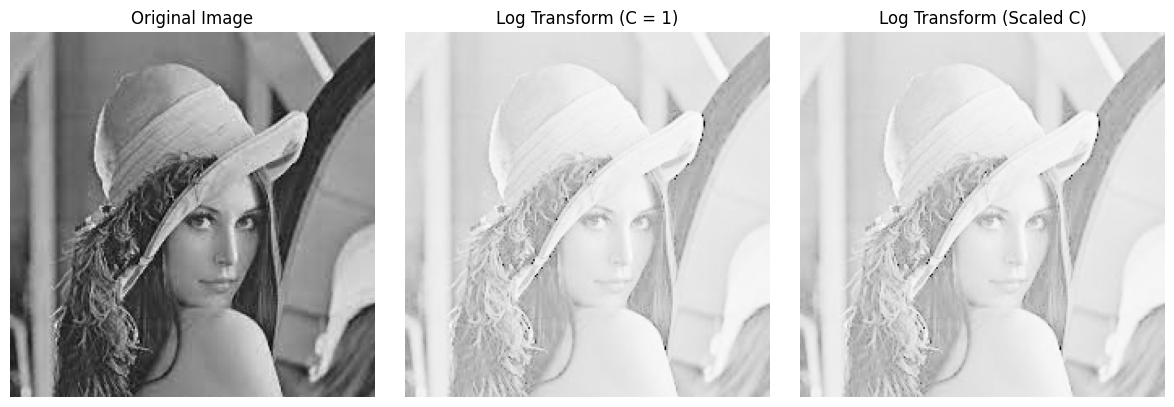

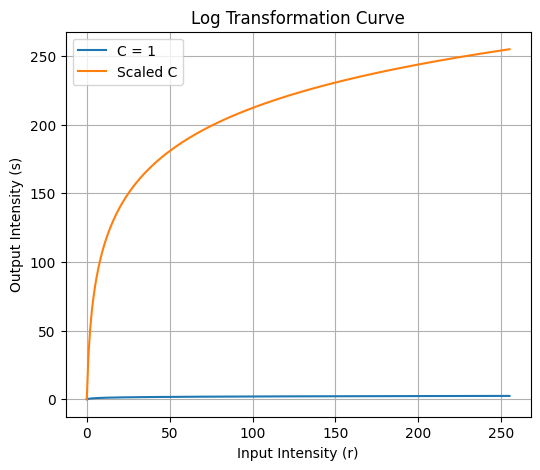

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read grayscale image
img = cv2.imread("a.jpg", cv2.IMREAD_GRAYSCALE)

# Convert to float to prevent overflow
img_float = img.astype(np.float64)

# Dynamically calculate bit depth
max_val = int(img.max())
bits = 0
temp = max_val
while temp > 0:
    bits += 1
    temp //= 2

L = 2 ** bits

# Case 1: C = 1
log_img_c1 = np.zeros_like(img_float)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        log_img_c1[i][j] = np.log10(1 + img_float[i][j])

# Normalize to full intensity range
log_img_c1 = (log_img_c1 / log_img_c1.max()) * (L - 1)
log_img_c1 = log_img_c1.astype(np.uint8)

# Case 2: Scaled C
C = (L - 1) / np.log10(1 + max_val)

log_img_scaled = np.zeros_like(img_float)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        log_img_scaled[i][j] = C * np.log10(1 + img_float[i][j])

log_img_scaled = np.clip(log_img_scaled, 0, L-1).astype(np.uint8)

# Show Images
# --------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=L-1)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(log_img_c1, cmap='gray', vmin=0, vmax=L-1)
plt.title("Log Transform (C = 1)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(log_img_scaled, cmap='gray', vmin=0, vmax=L-1)
plt.title("Log Transform (Scaled C)")
plt.axis('off')

plt.tight_layout()
plt.show()

# --------------------------
# Plot Transformation Curve
# --------------------------
r = np.arange(0, L)
s1 = np.log10(1 + r)
s2 = C * np.log10(1 + r)

plt.figure(figsize=(6,5))
plt.plot(r, s1, label="C = 1")
plt.plot(r, s2, label="Scaled C")
plt.title("Log Transformation Curve")
plt.xlabel("Input Intensity (r)")
plt.ylabel("Output Intensity (s)")
plt.legend()
plt.grid(True)
plt.show()